In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [172]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [173]:
df.shape

(7043, 21)

In [174]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [175]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [177]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [178]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [179]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [180]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [181]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [182]:
df.duplicated().sum()

np.int64(0)

In [183]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [184]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [185]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [186]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [187]:
df.drop("customerID", axis=1, inplace=True)

In [188]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


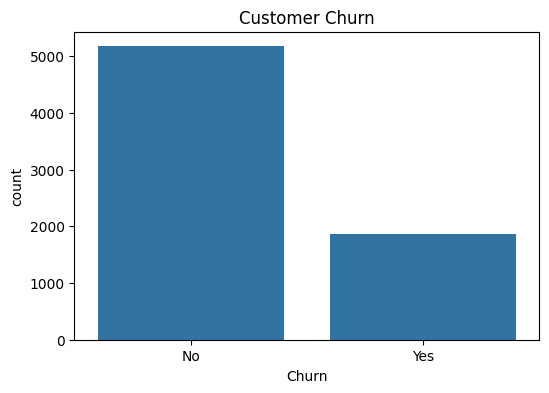

In [189]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.savefig("churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

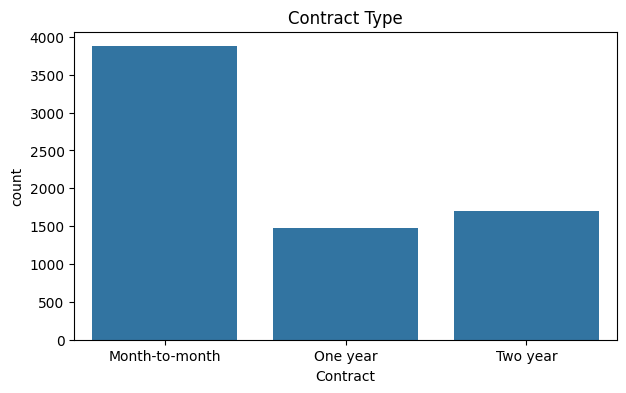

In [190]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", data=df)
plt.title("Contract Type")
plt.savefig("contract_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

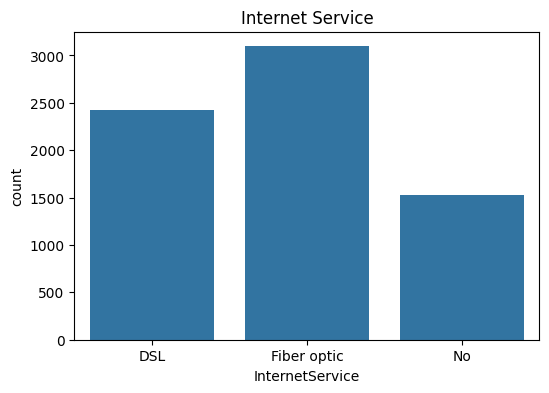

In [191]:
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", data=df)
plt.title("Internet Service")
plt.savefig("internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

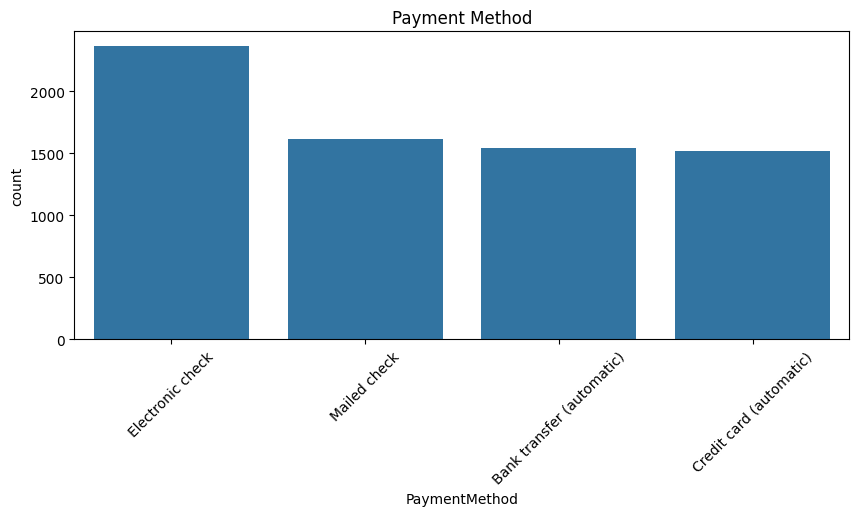

In [192]:
plt.figure(figsize=(10,4))
sns.countplot(x="PaymentMethod", data=df)
plt.xticks(rotation=45)
plt.title("Payment Method")
plt.savefig("payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

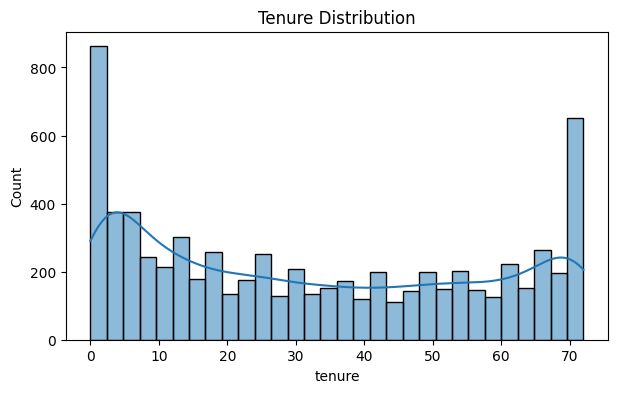

In [193]:
plt.figure(figsize=(7,4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.savefig("tenure_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

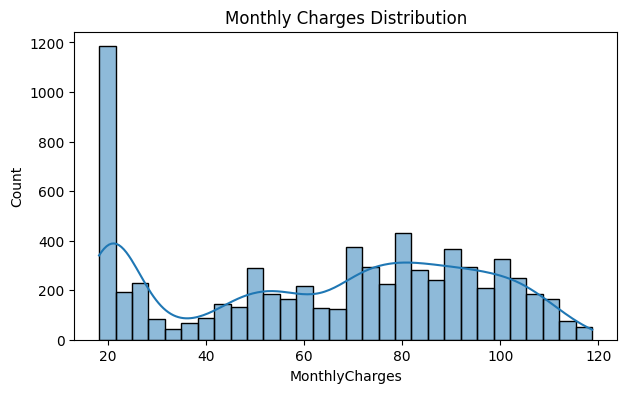

In [194]:
plt.figure(figsize=(7,4))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.savefig("monthly_charges_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

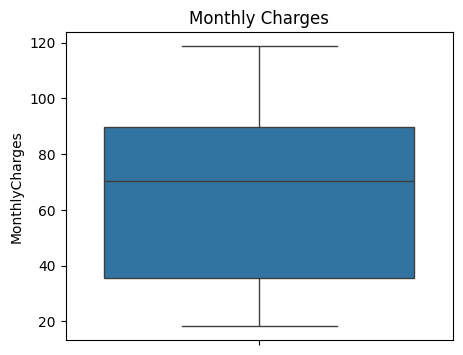

In [195]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df["MonthlyCharges"])
plt.title("Monthly Charges")
plt.savefig("monthly_charges_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

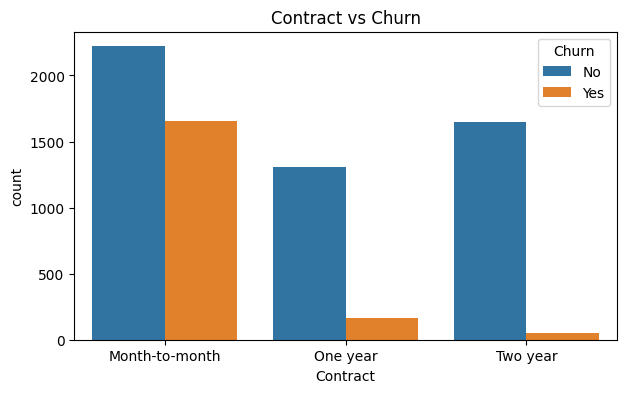

In [196]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract vs Churn")
plt.savefig("contract_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

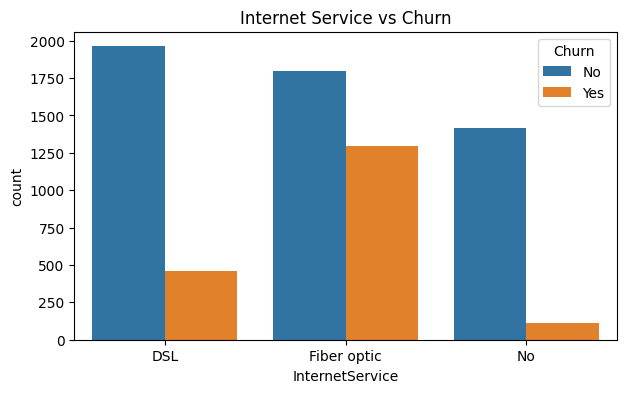

In [197]:
plt.figure(figsize=(7,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.savefig("internet_service_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

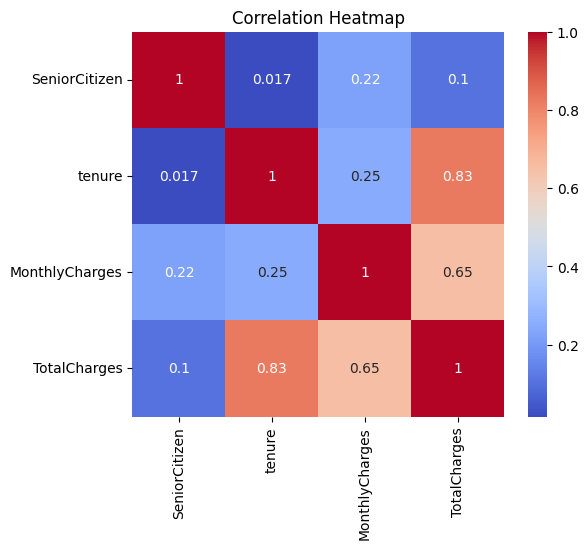

In [199]:
plt.figure(figsize=(6,5))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [200]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [201]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [202]:
df = pd.get_dummies(df, drop_first=True)

In [203]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [204]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [205]:
from sklearn.model_selection import train_test_split

In [206]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [207]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [208]:
from sklearn.preprocessing import StandardScaler

In [209]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [210]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [211]:
X_train.to_csv("X_train.csv", index=False)

X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)

y_test.to_csv("y_test.csv", index=False)

In [212]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.437749,-0.465683,-0.000474,-0.421345,-1.025166,-0.969579,1.532186,0.329573,-0.329573,-0.860523,...,-0.524081,-0.794748,-0.524081,1.250762,1.910109,-0.558353,-1.200007,-0.527656,-0.709650,1.84247
1,-0.437749,0.885537,1.074754,1.255888,-1.025166,-0.969579,-0.652662,0.329573,-0.329573,1.162083,...,-0.524081,1.258260,-0.524081,1.250762,-0.523530,1.790982,0.833328,-0.527656,-0.709650,-0.54275
2,-0.437749,-1.284605,-1.376499,-1.002151,0.975452,1.031376,-0.652662,-3.034225,3.034225,-0.860523,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.523530,-0.558353,0.833328,-0.527656,1.409146,-0.54275
3,-0.437749,-1.161766,0.177346,-0.907292,0.975452,-0.969579,-0.652662,0.329573,-0.329573,-0.860523,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.523530,-0.558353,0.833328,-0.527656,1.409146,-0.54275
4,-0.437749,-1.325551,-0.098524,-0.394513,0.975452,-0.969579,1.532186,0.329573,-0.329573,1.162083,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.523530,1.790982,0.833328,-0.527656,-0.709650,-0.54275


In [213]:
X_test.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.437749,-1.284605,-1.331629,-1.001554,-1.025166,1.031376,-0.652662,-3.034225,3.034225,-0.860523,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.52353,-0.558353,0.833328,-0.527656,1.409146,-0.54275
1,-0.437749,0.353238,-1.316672,-0.571859,0.975452,-0.969579,-0.652662,0.329573,-0.329573,1.162083,...,1.908103,-0.794748,1.908103,-0.799513,-0.52353,-0.558353,0.833328,-0.527656,-0.709650,-0.54275
2,-0.437749,0.803645,-1.512772,-0.556270,-1.025166,1.031376,1.532186,0.329573,-0.329573,-0.860523,...,1.908103,-0.794748,1.908103,-0.799513,-0.52353,1.790982,-1.200007,-0.527656,-0.709650,1.84247
3,-0.437749,-1.284605,0.381756,-0.978757,-1.025166,-0.969579,-0.652662,0.329573,-0.329573,-0.860523,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.52353,-0.558353,-1.200007,-0.527656,1.409146,-0.54275
4,-0.437749,1.417836,-0.475768,0.429201,0.975452,-0.969579,-0.652662,0.329573,-0.329573,-0.860523,...,-0.524081,-0.794748,-0.524081,-0.799513,-0.52353,1.790982,-1.200007,-0.527656,-0.709650,-0.54275


In [214]:
y_train.head()

,Churn
2142,0
1623,0
6074,1
1362,1
6754,0


In [215]:
y_test.head()

,Churn
185,1
2715,0
3825,0
1807,1
132,0


In [216]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (5634, 30)
X_test : (1409, 30)
y_train : (5634,)
y_test : (1409,)


In [217]:
from google.colab import files

files.download("X_train.csv")
files.download("X_test.csv")
files.download("y_train.csv")
files.download("y_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [220]:
files.download("churn_distribution.png")
files.download("contract_distribution.png")
files.download("internet_service.png")
files.download("payment_method.png")
files.download("tenure_distribution.png")
files.download("monthly_charges_distribution.png")
files.download("monthly_charges_boxplot.png")
files.download("contract_vs_churn.png")
files.download("internet_service_vs_churn.png")
files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>